In [1]:
import os
import cv2
import numpy as np
import glob
from collections import Counter

dataset_path = r"C:\Users\cathr\Downloads\archive (38)\data1a\validation"

In [2]:
import cv2
import numpy as np

def preprocess(img, method="bilateral"):
    """
    Preprocess image for CNN
    """

    # Resize image
    img = cv2.resize(img, (224, 224))

    # Apply noise reduction
    if method == "bilateral":
        img = cv2.bilateralFilter(img, 9, 75, 75)

    elif method == "gaussian":
        img = cv2.GaussianBlur(img, (5, 5), 0)

    elif method == "median":
        img = cv2.medianBlur(img, 5)

    # Convert to LAB color space
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    l, a, b = cv2.split(lab)

    # Apply CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)

    # Merge channels
    lab = cv2.merge((l, a, b))

    # Convert back to BGR
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    # Normalize pixel values
    img = img.astype(np.float32) / 255.0

    return img

In [3]:
def create_dataset(method):

    X = []
    y = []

    classes = {
        "00-damage":0,
        "01-whole":1
    }

    for class_name,label in classes.items():

        folder = os.path.join(dataset_path,class_name)

        image_paths = glob.glob(os.path.join(folder,"*.*"))

        print(class_name,len(image_paths))

        for img_path in image_paths:

            img = cv2.imread(img_path)

            if img is None:
                continue

            img = preprocess(img,method)

            X.append(img)
            y.append(label)

    X = np.array(X,dtype=np.float32)
    y = np.array(y)

    return X,y

In [4]:
X,y = create_dataset("bilateral")

print(X.shape)
print(y.shape)

print(Counter(y))

00-damage 245
01-whole 245
(485, 224, 224, 3)
(485,)
Counter({np.int64(0): 244, np.int64(1): 241})


In [5]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train,X_val,y_train,y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_model():

    model = Sequential()

    model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(128, (3,3), activation='relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(Flatten())

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(64, activation='relu'))

    model.add(Dense(2, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [7]:
import sys
print(sys.version)


3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [8]:
model = build_model()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=25,
    batch_size=32,
    shuffle=True
)


C:\Users\cathr\anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 105s 9s/step - accuracy: 0.4742 - loss: 0.7329 - val_accuracy: 0.5000 - val_loss: 0.6964
Epoch 2/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 70s 7s/step - accuracy: 0.5226 - loss: 0.7042 - val_accuracy: 0.5000 - val_loss: 0.6918
Epoch 3/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 67s 7s/step - accuracy: 0.5258 - loss: 0.6971 - val_accuracy: 0.5000 - val_loss: 0.6913
Epoch 4/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 66s 7s/step - accuracy: 0.6677 - loss: 0.6682 - val_accuracy: 0.5897 - val_loss: 0.6751
Epoch 5/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 66s 7s/step - accuracy: 0.6710 - loss: 0.6515 - val_accuracy: 0.6410 - val_loss: 0.6574
Epoch 6/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 69s 7s/step - accuracy: 0.7065 - loss: 0.6198 - val_accuracy: 0.6795 - val_loss: 0.6261
Epoch 7/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 65s 7s/step - accuracy: 0.7323 - loss: 0.5876 - val_accuracy: 0.6538 - val_loss: 0.6052
Epoch 8/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 64s 6s/step - accuracy: 0.7806 - loss: 0.5493 - val_accuracy: 0.6667 - val_loss

In [9]:
loss,accuracy = model.evaluate(X_test,y_test)

print("Test Accuracy:",accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 843ms/step - accuracy: 0.7526 - loss: 0.9165
Test Accuracy: 0.7525773048400879


Predicted Class : Whole
Confidence : 98.37%


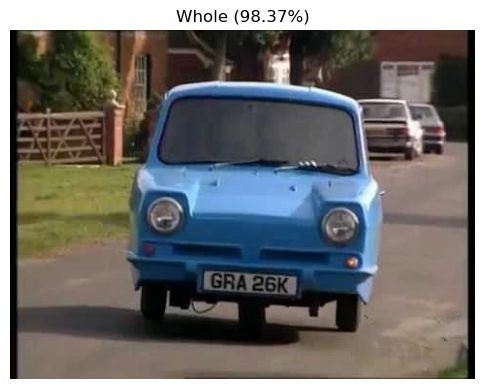

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Enter your test image path
# ----------------------------
image_path = r"C:\Users\cathr\OneDrive\Pictures\WhatsApp Image 2026-07-25 at 15.20.28.jpeg"
img = cv2.imread(image_path)

if img is None:
    print("Error: Unable to load image.")
else:
    # Keep original image for display
    original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Preprocess
    img = preprocess(img, "bilateral")

    # Add batch dimension
    img = np.expand_dims(img, axis=0)

    # Prediction
    prediction = model.predict(img, verbose=0)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction) * 100

    labels = {
        0: "Damage",
        1: "Whole"
    }

    print("Predicted Class :", labels[predicted_class])
    print("Confidence : {:.2f}%".format(confidence))

    # Display image
    plt.figure(figsize=(6,6))
    plt.imshow(original)
    plt.title(f"{labels[predicted_class]} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

Prediction : Not Found
Confidence : 61.56%
Raw Output : [[0.6156303  0.38436964]]


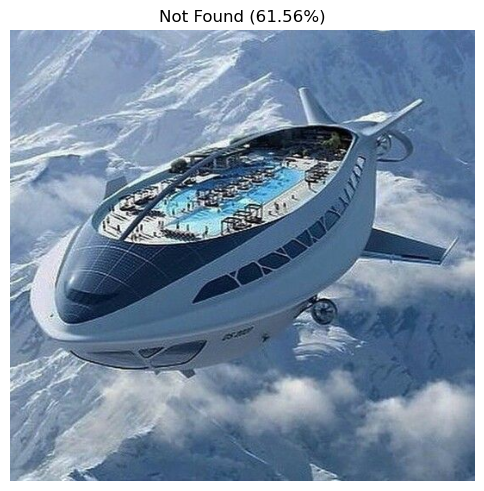

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"C:\Users\cathr\OneDrive\Pictures\cebb80055cd8b0d27c0374c7ec7fcec3.jpg"

img = cv2.imread(image_path)

if img is None:
    print("Error: Unable to load image.")

else:

    # Keep original image
    original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Preprocess
    img = preprocess(img, "bilateral")

    # Batch dimension
    img = np.expand_dims(img, axis=0)

    # Predict
    prediction = model.predict(img, verbose=0)

    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    labels = {
        0: "Damage",
        1: "Whole"
    }

    THRESHOLD = 80

    if confidence < THRESHOLD:
        result = "Not Found"
    else:
        result = labels[predicted_class]

    print("Prediction :", result)
    print(f"Confidence : {confidence:.2f}%")
    print("Raw Output :", prediction)

    plt.figure(figsize=(6,6))
    plt.imshow(original)
    plt.title(f"{result} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()